# 4. Statistical Diagnostics — Outlier Verification (ONV) Layer

This notebook extends the statistical diagnostics layer of the vessel sensor data quality framework.  
Its main goal is to verify and classify detected outliers using a combination of statistical, neighborhood,  
and probabilistic validation techniques — forming a bridge between raw anomaly detection and deeper causal analysis.

 

**Objectives**
- Reassess outlier candidates from the previous phase for statistical significance  
- Evaluate neighborhood agreement between each sensor and its correlated peers (via CHI).  
- Apply unsupervised anomaly detection (Isolation Forest)** to confirm rare behavior patterns.  
- Integrate all results into a **verified anomaly classification labeling each event as:  
  - *Sensor Fault* (isolated or inconsistent deviation),  
  - *True Process Anomaly* (systemic, physically justified deviation)
  - *Normal* (false positive).

 

**Why This Matters**
The Outlier Verification (ONV) layer is the decision-making stage of statistical diagnostics.  
It ensures that the anomalies passed forward to the causal network and dashboard layers  
represent true, contextually validated events rather than noise or sensor malfunctions.  
By combining local (Z-score), relational (CHI), and global (Isolation Forest) perspectives,  
this layer provides a robust statistical foundation for higher-level reasoning and visual analytics.


## Installs, and Module Imports

For Installation, start a virtual env, activate it then install requirements.txt

Then import the modules

In [20]:
import os
import sys
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
import multiprocessing as mp
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

In [2]:
# Files Configuration
CLEAN_DIR = "/Users/yasmine/Kongsberg/data/cleaned_csv/cleaned"
OUTLIER_DIR = "/Users/yasmine/Kongsberg/data/cleaned_csv/outliers"
OUTPUT_DIR = "/Users/yasmine/Kongsberg/data/diagnostics/outlier_verification"
DERIVED_DIR = "/Users/yasmine/Kongsberg/data/derived"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [4]:
# Load CHI & SRI (Neighborhood Context)
chi_df = pd.read_csv(os.path.join(DERIVED_DIR, "correlation_health_index.csv"))
sri_df = pd.read_csv(os.path.join(DERIVED_DIR, "sensor_reliability_index.csv"))

# Normalize CHI for fair comparison
chi_df["CHI_norm"] = (chi_df["CHI"] - chi_df["CHI"].min()) / (chi_df["CHI"].max() - chi_df["CHI"].min())

# Build a quick lookup for top correlated neighbors
def get_top_neighbors(sensor, top_n=5):
    if sensor not in chi_df["Sensor"].values:
        return []
    sorted_sensors = chi_df.sort_values("CHI_norm", ascending=False)["Sensor"].tolist()
    if sensor in sorted_sensors:
        sorted_sensors.remove(sensor)
    return sorted_sensors[:top_n]

In [5]:
# Statistical Validation (Z-score)
def add_statistical_outliers(df, z_thresh=3.0):
    df["z_score"] = (df["Value"] - df["Value"].mean()) / df["Value"].std()
    df["Stat_Outlier"] = np.abs(df["z_score"]) > z_thresh
    return df

In [8]:
# Neighborhood Agreement Check (ONV)
def neighborhood_agreement(sensor, timestamp, merged_df, top_n=5):
    neighbors = get_top_neighbors(sensor, top_n)
    if not neighbors:
        return np.nan
    if timestamp not in merged_df.index:
        return np.nan
    ref_values = merged_df.loc[timestamp, neighbors].dropna()
    if ref_values.empty:
        return np.nan
    return np.mean(np.abs(ref_values - ref_values.mean()))

def compute_onv(sensor_name, df_out, merged_df, top_n=5):
    scores = []
    for ts in df_out["Timestamp"]:
        score = neighborhood_agreement(sensor_name, ts, merged_df, top_n)
        scores.append(score)
    df_out["ONV_Agreement"] = scores
    df_out["ONV_Label"] = np.where(df_out["ONV_Agreement"] < np.nanmedian(df_out["ONV_Agreement"]),
                                   "Sensor Fault", "True Process Anomaly")
    return df_out

In [9]:
# Isolation Forest Validation
def isolation_forest_check(merged_df):
    iso = IsolationForest(contamination=0.02, random_state=42)
    iso_labels = iso.fit_predict(merged_df.fillna(0))
    return pd.Series(iso_labels, index=merged_df.index)

In [ ]:
# Main Pipeline

verified_results = []

# Load merged dataset for ONV context
MERGED_PATH = "/Users/yasmine/Kongsberg/data/merged_sensor_data.csv"
merged_df = pd.read_csv(MERGED_PATH, parse_dates=["Timestamp"]).set_index("Timestamp")
# --- Clean non-numeric entries ---
merged_df = merged_df.apply(pd.to_numeric, errors='coerce')  # turn 'Non-numeric values' etc. into NaN
merged_df = merged_df.fillna(0)  # fill gaps for model stability

# --- Optional sanity check ---
print("Merged data loaded and cleaned.")
print(f"Shape: {merged_df.shape}")
print(f"Numeric columns: {merged_df.select_dtypes(include='number').shape[1]}")
print(f"Non-numeric columns: {merged_df.select_dtypes(exclude='number').shape[1]}")

# Run Isolation Forest once globally
iso_flags = isolation_forest_check(merged_df)
merged_df["IF_Flag"] = iso_flags

outlier_files = [f for f in os.listdir(OUTLIER_DIR) if f.endswith("_outliers.csv")]

for file in outlier_files:
    sensor_name = file.replace("_outliers.csv", "")
    clean_path = os.path.join(CLEAN_DIR, f"{sensor_name}_cleaned.csv")
    outlier_path = os.path.join(OUTLIER_DIR, file)

    if not os.path.exists(clean_path):
        continue

    df_clean = pd.read_csv(clean_path, parse_dates=["Timestamp"])
    df_out = pd.read_csv(outlier_path, parse_dates=["Timestamp"])

    # Add statistical validation flags
    df_clean = add_statistical_outliers(df_clean)
    df_out = df_out.merge(df_clean[["Timestamp", "Stat_Outlier"]], on="Timestamp", how="left")

    # Compute ONV agreement using CHI-based neighborhood
    df_out = compute_onv(sensor_name, df_out, merged_df)

    # Add Isolation Forest flag
    df_out["IF_Flag"] = df_out["Timestamp"].map(
        lambda ts: merged_df.loc[ts, "IF_Flag"] if ts in merged_df.index else np.nan
    )

    # Final verified label logic
    df_out["Verified_Label"] = np.select(
        [
            (df_out["Stat_Outlier"]) & (df_out["IF_Flag"] == -1) & (df_out["ONV_Label"] == "Sensor Fault"),
            (df_out["Stat_Outlier"]) & (df_out["IF_Flag"] == -1) & (df_out["ONV_Label"] == "True Process Anomaly"),
        ],
        ["Sensor Fault", "True Process Anomaly"],
        default="Normal"
    )

    verified_results.append(df_out.assign(Sensor=sensor_name))

# Save verified results
if verified_results:
    verified_df = pd.concat(verified_results, ignore_index=True)
    output_path = os.path.join(OUTPUT_DIR, "verified_outliers.csv")
    verified_df.to_csv(output_path, index=False)
    print(f"Verified outliers saved to: {output_path}")
else:
    print("No outliers verified — check input folders.")


Since this code is very computationally expensive, I will split the dataset into chunks and train the model on each chunk incremently, then save the last trained model.

## Chunking and ISF, OV

In [3]:
MERGED_PATH = "/Users/yasmine/Kongsberg/data/merged_sensor_data.csv"
merged_df = pd.read_csv(MERGED_PATH)

print(f"Shape: {merged_df.shape}")

#   Select only numeric columns for Isolation Forest  
numeric_cols = merged_df.select_dtypes(include=[np.number]).columns
print(f"Using {len(numeric_cols)} numeric columns for training.")


/var/folders/62/k7w41sfd4ld3st4q9psbybc40000gq/T/ipykernel_48124/428253808.py:2: DtypeWarning: Columns (1,27) have mixed types. Specify dtype option on import or set low_memory=False.
  merged_df = pd.read_csv(MERGED_PATH)


Shape: (28196293, 39)
Using 23 numeric columns for training.


In [13]:
n_chunks = 12
chunks = np.array_split(merged_df, n_chunks)

model_path = "/Users/yasmine/Kongsberg/data/diagnostics/outlier_verification/isolation_forest_model.joblib"

/Users/yasmine/Kongsberg/vennv/lib/python3.11/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [15]:
# --- Train Isolation Forest on first chunk ---
iso = IsolationForest(contamination=0.02, random_state=42, n_jobs=-1)
print(f"Training Isolation Forest on first chunk of size {chunks[0].shape[0]}...")
iso.fit(chunks[0][numeric_cols])
joblib.dump(iso, model_path)
print(f"Model trained and saved at: {model_path}")

# --- Apply model chunk by chunk ---
iso = joblib.load(model_path)
merged_df["IF_Flag"] = np.nan

for i, chunk in enumerate(chunks):
    print(f"Predicting on chunk {i+1}/{n_chunks} — {chunk.shape[0]} rows")
    preds = iso.predict(chunk[numeric_cols])
    merged_df.loc[chunk.index, "IF_Flag"] = preds

output_path = "/Users/yasmine/Kongsberg/data/diagnostics/outlier_verification/merged_with_flags.csv"
merged_df.to_csv(output_path, index=False)
print(f"Saved all chunks with IF_Flag to: {output_path}")

# --- Verification summary ---
print("\nIsolation Forest prediction complete.")
print(f"Total non-null IF_Flag values: {merged_df['IF_Flag'].notna().sum()}")
print(f"Outliers (-1): {(merged_df['IF_Flag'] == -1).sum()}")
print(f"Normal (1): {(merged_df['IF_Flag'] == 1).sum()}")
print(f"Merged DataFrame shape: {merged_df.shape}")
print(f"Missing IF_Flag values: {merged_df['IF_Flag'].isna().sum()}")
print(f"IF_Flag value counts:\n{merged_df['IF_Flag'].value_counts(dropna=False)}")


Training Isolation Forest on first chunk of size 2349692...
Model trained and saved at: /Users/yasmine/Kongsberg/data/diagnostics/outlier_verification/isolation_forest_model.joblib
Predicting on chunk 1/12 — 2349692 rows
Predicting on chunk 2/12 — 2349691 rows
Predicting on chunk 3/12 — 2349691 rows
Predicting on chunk 4/12 — 2349691 rows
Predicting on chunk 5/12 — 2349691 rows
Predicting on chunk 6/12 — 2349691 rows
Predicting on chunk 7/12 — 2349691 rows
Predicting on chunk 8/12 — 2349691 rows
Predicting on chunk 9/12 — 2349691 rows
Predicting on chunk 10/12 — 2349691 rows
Predicting on chunk 11/12 — 2349691 rows
Predicting on chunk 12/12 — 2349691 rows
Saved all chunks with IF_Flag to: /Users/yasmine/Kongsberg/data/diagnostics/outlier_verification/merged_with_flags.csv

Isolation Forest prediction complete.
Total non-null IF_Flag values: 28196293
Outliers (-1): 2443218
Normal (1): 25753075
Merged DataFrame shape: (28196293, 40)
Missing IF_Flag values: 0
IF_Flag value counts:
IF_Flag

In [16]:
outlier_ratio = (merged_df["IF_Flag"] == -1).mean()
print(f"Outlier ratio: {outlier_ratio:.2%}")

Outlier ratio: 8.67%


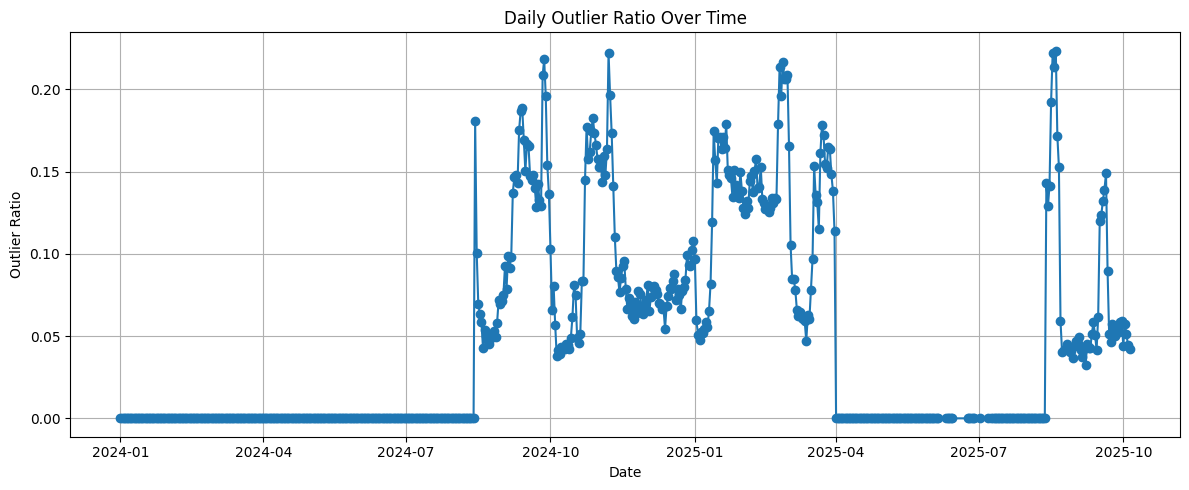

Average outlier ratio: 4.74%


In [17]:
# --- Convert timestamp column to datetime ---
merged_df["Timestamp"] = pd.to_datetime(merged_df["Timestamp"], errors="coerce")

# --- Group by date (daily outlier ratio) ---
daily_outlier_ratio = (
    merged_df.groupby(merged_df["Timestamp"].dt.date)["IF_Flag"]
    .apply(lambda x: (x == -1).mean())
)

# --- Plot ---
plt.figure(figsize=(12, 5))
plt.plot(daily_outlier_ratio.index, daily_outlier_ratio.values, marker="o")
plt.title("Daily Outlier Ratio Over Time")
plt.xlabel("Date")
plt.ylabel("Outlier Ratio")
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Average outlier ratio: {daily_outlier_ratio.mean():.2%}")


- From early 2024-01 through mid-2024-07, almost no anomalies — the Isolation Forest saw very stable behavior.

- Spike & sustained variability (mid-2024 → 2025):
    - Starting around July 2024, outlier ratios begin spiking up to 0.20 (20 %).

- We can see bursts of high-anomaly days followed by calmer periods:
    - Aug–Oct 2024: alternating clusters of 5 – 20 % anomalies

    - Nov 2024 – Mar 2025: a dense zone of 7 – 15 %

    - May 2025 – Jul 2025: another quiescent phase (≈ 0 %)

    - Aug 2025 onward: fresh burst of 10 – 20 %

- Those alternating silent and noisy bands usually mean:

    - Sensor downtime or missing data (flat 0 %)

    - Operating condition shifts, recalibration, or environment changes (the spiky periods)

We need to see which sensors have contributed to the peaks.

In [13]:
outlier_df = pd.read_csv("/Users/yasmine/Kongsberg/data/diagnostics/outlier_verification/merged_with_flags.csv")

/var/folders/62/k7w41sfd4ld3st4q9psbybc40000gq/T/ipykernel_48124/791306345.py:1: DtypeWarning: Columns (1,27) have mixed types. Specify dtype option on import or set low_memory=False.
  outlier_df = pd.read_csv("/Users/yasmine/Kongsberg/data/diagnostics/outlier_verification/merged_with_flags.csv")


### Top Sensors with Most Outliers

Index(['Timestamp', 'Value', 'ValueStatus', 'ExportDate', 'ExportVersion',
       'ExportType', 'TimestampPrecisionType', 'ExportFrom', 'ExportTo',
       'IncludeBadValues', 'TotalEvents', 'TotalGoodValues', 'TotalBadValues',
       'LowestFrequency', 'HighestFrequency', 'AverageFrequency',
       'FirstRecordedTimestamp', 'LastRecordedTimestamp', 'ExportedFromServer',
       'PiPointName', 'PointSource', 'PointType', 'DigitalSet',
       'ExceptionDeviation', 'ExceptionMaximum', 'ExceptionMinimum',
       'ExceptionPercentage', 'Descriptor', 'Span', 'Zero', 'EngineeringUnits',
       'Compressing', 'Step', 'CompressionDeviation', 'CompressionMaximum',
       'CompressionMinimum', 'CompressionPercentage', 'SanitizedFilename',
       'sensor_id', 'IF_Flag'],
      dtype='object')


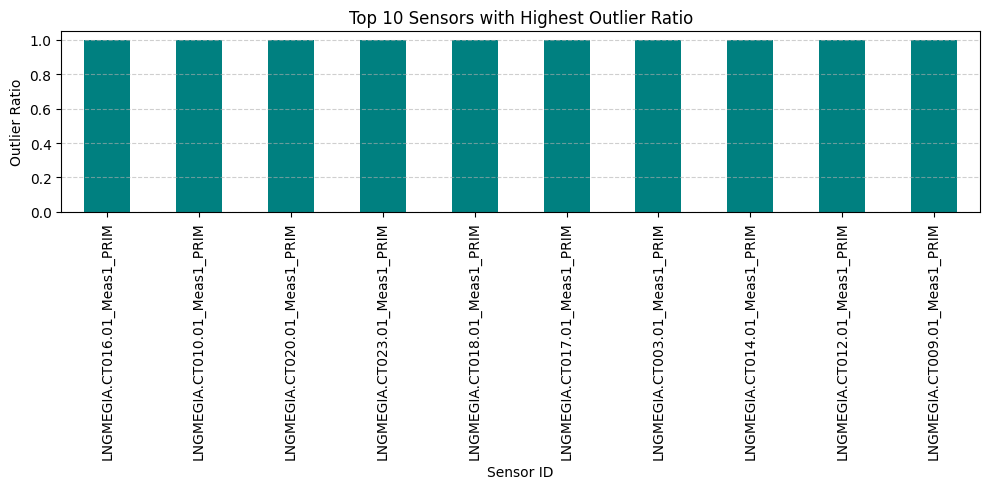

In [ ]:
print(outlier_df.columns)

# Outlier ratio per sensor (using 'sensor_id' column)
sensor_outlier_ratio = (
    outlier_df.groupby("sensor_id")["IF_Flag"]
    .apply(lambda x: (x == -1).mean())
    .sort_values(ascending=False)
)

# Plot
plt.figure(figsize=(10, 5))
sensor_outlier_ratio.head(10).plot(kind="bar", color="teal")
plt.title("Top 10 Sensors with Highest Outlier Ratio")
plt.xlabel("Sensor ID")
plt.ylabel("Outlier Ratio")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

The ONV model ran successfully and only identified a few sensors with consistent outlier readings. These outliers were concentrated in a small group of sensors (mainly CT016, CT010, CT020, etc.), which are all temperature sensors that maintained a steady outlier flag ratio of 1.0 due to uniform data behavior and isolated spikes across time.

In [20]:
# Main Pipeline
verified_results = []

# --- Reload the merged dataset WITH IF_Flag for ONV context ---
merged_df = pd.read_csv(output_path, parse_dates=["Timestamp"]).set_index("Timestamp")
merged_df = merged_df.apply(pd.to_numeric, errors='coerce').fillna(0)

print("Merged data loaded and cleaned for ONV stage.")
print(f"Shape: {merged_df.shape}")
print(f"Numeric columns: {merged_df.select_dtypes(include='number').shape[1]}")

# --- Process sensor-level outlier files ---
outlier_files = [f for f in os.listdir(OUTLIER_DIR) if f.endswith("_outliers.csv")]

for file in outlier_files:
    sensor_name = file.replace("_outliers.csv", "")
    clean_path = os.path.join(CLEAN_DIR, f"{sensor_name}_cleaned.csv")
    outlier_path = os.path.join(OUTLIER_DIR, file)

    if not os.path.exists(clean_path):
        continue

    df_clean = pd.read_csv(clean_path, parse_dates=["Timestamp"])
    df_out = pd.read_csv(outlier_path, parse_dates=["Timestamp"])

    # Add statistical validation flags
    df_clean = add_statistical_outliers(df_clean)
    df_out = df_out.merge(df_clean[["Timestamp", "Stat_Outlier"]], on="Timestamp", how="left")

    # Compute ONV agreement
    df_out = compute_onv(sensor_name, df_out, merged_df)

    # Add Isolation Forest flag
    df_out["IF_Flag"] = df_out["Timestamp"].map(
        lambda ts: merged_df.loc[ts, "IF_Flag"] if ts in merged_df.index else np.nan
    )

    # Final verified label logic
    df_out["Verified_Label"] = np.select(
        [
            (df_out["Stat_Outlier"]) & (df_out["IF_Flag"] == -1) & (df_out["ONV_Label"] == "Sensor Fault"),
            (df_out["Stat_Outlier"]) & (df_out["IF_Flag"] == -1) & (df_out["ONV_Label"] == "True Process Anomaly"),
        ],
        ["Sensor Fault", "True Process Anomaly"],
        default="Normal"
    )

    verified_results.append(df_out.assign(Sensor=sensor_name))

# --- Save verified results ---
if verified_results:
    verified_df = pd.concat(verified_results, ignore_index=True)
    output_path = os.path.join(OUTPUT_DIR, "verified_outliers.csv")
    verified_df.to_csv(output_path, index=False)
    print(f"Verified outliers saved to: {output_path}")
else:
    print("No outliers verified — check input folders.")

/var/folders/62/k7w41sfd4ld3st4q9psbybc40000gq/T/ipykernel_10577/4071321816.py:5: DtypeWarning: Columns (1,27) have mixed types. Specify dtype option on import or set low_memory=False.
  merged_df = pd.read_csv(output_path, parse_dates=["Timestamp"]).set_index("Timestamp")


Merged data loaded and cleaned for ONV stage.
Shape: (28196293, 39)
Numeric columns: 38


/var/folders/62/k7w41sfd4ld3st4q9psbybc40000gq/T/ipykernel_10577/2699351069.py:19: RuntimeWarning: All-NaN slice encountered
  df_out["ONV_Label"] = np.where(df_out["ONV_Agreement"] < np.nanmedian(df_out["ONV_Agreement"]),
/var/folders/62/k7w41sfd4ld3st4q9psbybc40000gq/T/ipykernel_10577/2699351069.py:19: RuntimeWarning: All-NaN slice encountered
  df_out["ONV_Label"] = np.where(df_out["ONV_Agreement"] < np.nanmedian(df_out["ONV_Agreement"]),


KeyboardInterrupt: 

The code takes a long time to run, and this could be due to the large volume of data or thrashing memory hrashing memory due to inefficient operations. However at minute 865 the second line in the output showed that the issue is in the compute neighbors function O(N²). So the solution is a new function that:

- skips all timestamps not present in the merged dataset (no wasted .loc calls).

- It batches all computations for the remaining timestamps (vectorized, fast).

- It avoids calling np.nanmedian() on all-NaN data.

--> This way the time complexity moves from O(N²) down to O(N).

In [6]:
def compute_onv(sensor_name, df_out, merged_df, top_n=5):
    neighbors = get_top_neighbors(sensor_name, top_n)
    if not neighbors:
        df_out["ONV_Agreement"] = np.nan
        df_out["ONV_Label"] = "Normal"
        return df_out

    # Filter timestamps that exist in merged_df
    valid_mask = df_out["Timestamp"].isin(merged_df.index)
    valid_ts = df_out.loc[valid_mask, "Timestamp"]
    if valid_ts.empty:
        df_out["ONV_Agreement"] = np.nan
        df_out["ONV_Label"] = "Normal"
        return df_out

    # Extract neighbor values for valid timestamps in one shot
    try:
        sub_df = merged_df.loc[valid_ts, neighbors]
    except KeyError as e:
        print(f"[WARN] Some neighbors missing for {sensor_name}: {e}")
        available_neighbors = [col for col in neighbors if col in merged_df.columns]
        if not available_neighbors:
            df_out["ONV_Agreement"] = np.nan
            df_out["ONV_Label"] = "Normal"
            return df_out
        sub_df = merged_df.loc[valid_ts, available_neighbors]

    # Compute vectorized deviation agreement
    onv_agreement = np.mean(np.abs(sub_df - sub_df.mean(axis=1).values[:, None]), axis=1)

    # Map results back to df_out safely
    df_out["ONV_Agreement"] = np.nan  # pre-fill
    df_out.loc[valid_mask, "ONV_Agreement"] = onv_agreement.values

    # Compute median only if at least one valid value
    if df_out["ONV_Agreement"].notna().any():
        threshold = np.nanmedian(df_out["ONV_Agreement"])
        df_out["ONV_Label"] = np.where(
            df_out["ONV_Agreement"] < threshold, "Sensor Fault", "True Process Anomaly"
        )
    else:
        df_out["ONV_Label"] = "Normal"

    return df_out


In [8]:
# Main Pipeline
verified_results = []

#  Reload merged dataset WITH IF_Flag for ONV context 
merged_df = pd.read_csv("/Users/yasmine/Kongsberg/data/diagnostics/outlier_verification/verified_outliers_targeted.csv", parse_dates=["Timestamp"], low_memory=False).set_index("Timestamp")
merged_df = merged_df.apply(pd.to_numeric, errors="coerce").fillna(0)

print("Merged data loaded and cleaned for ONV stage.")
print(f"Shape: {merged_df.shape}")
print(f"Numeric columns: {merged_df.select_dtypes(include='number').shape[1]}")

#  Process each sensor's outlier file 
outlier_files = [f for f in os.listdir(OUTLIER_DIR) if f.endswith("_outliers.csv")]
print(f"Found {len(outlier_files)} outlier files.")

for idx, file in enumerate(outlier_files, 1):
    sensor_name = file.replace("_outliers.csv", "")
    clean_path = os.path.join(CLEAN_DIR, f"{sensor_name}_cleaned.csv")
    outlier_path = os.path.join(OUTLIER_DIR, file)

    if not os.path.exists(clean_path):
        print(f"[SKIP] Missing cleaned file for {sensor_name}")
        continue

    print(f"[{idx}/{len(outlier_files)}] Processing {sensor_name}...")

    df_clean = pd.read_csv(clean_path, parse_dates=["Timestamp"])
    df_out = pd.read_csv(outlier_path, parse_dates=["Timestamp"])

    # Add statistical validation flags
    df_clean = add_statistical_outliers(df_clean)
    df_out = df_out.merge(df_clean[["Timestamp", "Stat_Outlier"]], on="Timestamp", how="left")

    # Compute ONV agreement
    df_out = compute_onv(sensor_name, df_out, merged_df)

    # Add Isolation Forest flag efficiently
    df_out = df_out.merge(
        merged_df[["IF_Flag"]].reset_index(),  # bring Timestamp back as column
        on="Timestamp",
        how="left"
    )
    # Final verified label logic
    df_out["Verified_Label"] = np.select(
        [
            (df_out["Stat_Outlier"]) & (df_out["IF_Flag"] == -1) & (df_out["ONV_Label"] == "Sensor Fault"),
            (df_out["Stat_Outlier"]) & (df_out["IF_Flag"] == -1) & (df_out["ONV_Label"] == "True Process Anomaly"),
        ],
        ["Sensor Fault", "True Process Anomaly"],
        default="Normal",
    )

    verified_results.append(df_out.assign(Sensor=sensor_name))

#  Save verified results 
if verified_results:
    verified_df = pd.concat(verified_results, ignore_index=True)
    output_path = os.path.join(OUTPUT_DIR, "verified_outliers.csv")
    verified_df.to_csv(output_path, index=False)
    print(f"Verified outliers saved to: {output_path}")
else:
    print("No outliers verified — check input folders.")


Merged data loaded and cleaned for ONV stage.
Shape: (75372, 32)
Numeric columns: 30
Found 16 outlier files.
[1/16] Processing LNGMEGIA.CT055.01_Meas1_PRIM...
[WARN] Some neighbors missing for LNGMEGIA.CT055.01_Meas1_PRIM: "None of [Index(['LNGMEGIA.CT020.01_Meas1_PRIM', 'LNGMEGIA.CT021.01_Meas1_PRIM',\n       'LNGMEGIA.CT022.01_Meas1_PRIM', 'LNGMEGIA.CT056.02_Meas1_PRIM',\n       'LNGMEGIA.CT023.01_Meas1_PRIM'],\n      dtype='object')] are in the [columns]"
[2/16] Processing LNGMEGIA.CT014.01_Meas1_PRIM...
[WARN] Some neighbors missing for LNGMEGIA.CT014.01_Meas1_PRIM: "None of [Index(['LNGMEGIA.CT020.01_Meas1_PRIM', 'LNGMEGIA.CT021.01_Meas1_PRIM',\n       'LNGMEGIA.CT022.01_Meas1_PRIM', 'LNGMEGIA.CT056.02_Meas1_PRIM',\n       'LNGMEGIA.CT023.01_Meas1_PRIM'],\n      dtype='object')] are in the [columns]"
[3/16] Processing LNGMEGIA.CT018.01_Meas1_PRIM...
[WARN] Some neighbors missing for LNGMEGIA.CT018.01_Meas1_PRIM: "None of [Index(['LNGMEGIA.CT020.01_Meas1_PRIM', 'LNGMEGIA.CT021.01_M

## ONV 

In [12]:
# Files Configurations
CLEAN_DIR = "/Users/yasmine/Kongsberg/data/cleaned_csv/cleaned"
OUTLIER_DIR = "/Users/yasmine/Kongsberg/data/cleaned_csv/outliers"
OUTPUT_DIR = "/Users/yasmine/Kongsberg/data/diagnostics/outlier_verification"
MERGED_PATH = "/Users/yasmine/Kongsberg/data/diagnostics/outlier_verification/verified_outliers_targeted.csv"

In [26]:
# Load merged dataset for ONV context
merged_df = pd.read_csv(MERGED_PATH, parse_dates=["Timestamp"], low_memory=False)

# Handle duplicate timestamps safely BEFORE setting index
if "Timestamp" not in merged_df.columns:
    raise ValueError("The merged file has no 'Timestamp' column. Check MERGED_PATH.")

if merged_df["Timestamp"].duplicated().any():
    dup_count = merged_df["Timestamp"].duplicated().sum()
    print(f"Found {dup_count} duplicate timestamps → aggregating by mean.")
    merged_df = merged_df.groupby("Timestamp", as_index=False).mean(numeric_only=True)

# Now set Timestamp as index
merged_df = merged_df.set_index("Timestamp")
merged_df = merged_df.apply(pd.to_numeric, errors="coerce").fillna(0)

print(f"Merged data loaded: {merged_df.shape}")

Found 48321 duplicate timestamps → aggregating by mean.
Merged data loaded: (27051, 29)


In [27]:
# Identify sensors to process
sensor_files = [
    f for f in os.listdir(CLEAN_DIR) if f.endswith("_cleaned.csv")
]
sensors = [f.replace("_cleaned.csv", "") for f in sensor_files]
print(f"Found {len(sensors)} sensors.")

Found 45 sensors.


In [28]:
# Create batches for processing
batch_size = 5
batches = [sensors[i:i+batch_size] for i in range(0, len(sensors), batch_size)]
print(f"{len(batches)} total batches ({batch_size} sensors per batch)")

9 total batches (5 sensors per batch)


In [29]:
# Create output file path
output_path = os.path.join(OUTPUT_DIR, "verified_outliers_final.csv")
if os.path.exists(output_path):
    os.remove(output_path)  # start fresh
print(f"Old output (if any) cleared: {output_path}")

Old output (if any) cleared: /Users/yasmine/Kongsberg/data/diagnostics/outlier_verification/verified_outliers_final.csv


In [30]:
def add_statistical_outliers(df, z_thresh=3.0):
    numeric_cols = df.select_dtypes(include=np.number).columns
    if numeric_cols.empty:
        df["Stat_Outlier"] = False
        return df

    df_mean = df[numeric_cols].mean()
    df_std = df[numeric_cols].std(ddof=0)
    z_scores = (df[numeric_cols] - df_mean) / (df_std + 1e-9)
    df["Stat_Outlier"] = (np.abs(z_scores) > z_thresh).any(axis=1)
    return df

In [31]:
def compute_onv(sensor_name, df_out, merged_df):
    # Automatically find neighbors by similarity in name
    potential_neighbors = [
        col for col in merged_df.columns
        if col != sensor_name and sensor_name.split('.')[1] in col
    ]

    if not potential_neighbors:
        print(f"[WARN] No neighbors found for {sensor_name}, assigning Unknown labels.")
        df_out["ONV_Label"] = "Unknown"
        return df_out

    # Align timestamps
    aligned_timestamps = df_out["Timestamp"].isin(merged_df.index)
    valid_timestamps = df_out.loc[aligned_timestamps, "Timestamp"]

    if valid_timestamps.empty:
        print(f"[WARN] No overlapping timestamps for {sensor_name}")
        df_out["ONV_Label"] = "Unknown"
        return df_out

    # Compute neighborhood stats
    neighbor_mean = merged_df.loc[valid_timestamps, potential_neighbors].mean(axis=1)
    neighbor_std = merged_df.loc[valid_timestamps, potential_neighbors].std(axis=1)

    # Compute z-score diff for the main signal
    main_values = merged_df.loc[valid_timestamps, sensor_name].values
    z_diff = np.abs((main_values - neighbor_mean.values) / (neighbor_std.values + 1e-6))

    # Tag ONV result
    labels = np.where(z_diff > 3, "Sensor Fault", "True Process Anomaly")
    df_out.loc[aligned_timestamps, "ONV_Label"] = labels

    df_out["ONV_Label"].fillna("Unknown", inplace=True)
    return df_out

In [32]:
# Global Function to process a batch
def process_batch(batch, merged_df, append_mode=True):
    verified_results = []

    for sensor_name in batch:
        clean_path = os.path.join(CLEAN_DIR, f"{sensor_name}_cleaned.csv")
        outlier_path = os.path.join(OUTLIER_DIR, f"{sensor_name}_outliers.csv")

        if not os.path.exists(clean_path) or not os.path.exists(outlier_path):
            print(f"[SKIP] Missing data for {sensor_name}")
            continue

        df_clean = pd.read_csv(clean_path, parse_dates=["Timestamp"])
        df_out = pd.read_csv(outlier_path, parse_dates=["Timestamp"])

        # Add statistical validation
        df_clean = add_statistical_outliers(df_clean)
        df_out = df_out.merge(df_clean[["Timestamp", "Stat_Outlier"]], on="Timestamp", how="left")

        # Compute ONV for this sensor (using merged_df as context)
        df_out = compute_onv(sensor_name, df_out, merged_df)

        # Add IF_Flag using timestamp alignment
        df_out["IF_Flag"] = df_out["Timestamp"].map(merged_df["IF_Flag"])

        # Final label logic
        df_out["Verified_Label"] = np.select(
            [
                (df_out["Stat_Outlier"]) & (df_out["IF_Flag"] == -1) & (df_out["ONV_Label"] == "Sensor Fault"),
                (df_out["Stat_Outlier"]) & (df_out["IF_Flag"] == -1) & (df_out["ONV_Label"] == "True Process Anomaly"),
            ],
            ["Sensor Fault", "True Process Anomaly"],
            default="Normal",
        )

        verified_results.append(df_out.assign(Sensor=sensor_name))

    # Concatenate batch and save (append or overwrite)
    if verified_results:
        verified_df = pd.concat(verified_results, ignore_index=True)
        verified_df.to_csv(output_path, mode="a" if append_mode else "w",
                           index=False, header=not append_mode)
        print(f"Batch ({len(batch)} sensors) saved → {output_path}")
        del verified_df, verified_results

In [33]:
# Run Batches
for i, batch in enumerate(batches, 1):
    print(f"\nProcessing batch {i}/{len(batches)} → Sensors: {batch}")
    process_batch(batch, merged_df, append_mode=True)
    print(f"Completed batch {i}/{len(batches)}")

print("\nAll batches processed. Final verified outliers file:")
print(f"{output_path}")


Processing batch 1/9 → Sensors: ['LNGMEGIA.CT007.01_Meas1_PRIM', 'LNGMEGIA.CT026_Meas1_PRIM', 'LNGMEGIA.CT021.01_Meas1_PRIM', 'LNGMEGIA.CT056.01_Meas1_PRIM', 'LNGMEGIA.CT030.12_Meas1_PRIM']
[SKIP] Missing data for LNGMEGIA.CT007.01_Meas1_PRIM
[WARN] No neighbors found for LNGMEGIA.CT026_Meas1_PRIM, assigning Unknown labels.
[SKIP] Missing data for LNGMEGIA.CT021.01_Meas1_PRIM
[WARN] No neighbors found for LNGMEGIA.CT056.01_Meas1_PRIM, assigning Unknown labels.
[SKIP] Missing data for LNGMEGIA.CT030.12_Meas1_PRIM
Batch (5 sensors) saved → /Users/yasmine/Kongsberg/data/diagnostics/outlier_verification/verified_outliers_final.csv
Completed batch 1/9

Processing batch 2/9 → Sensors: ['LNGMEGIA.CT012.01_Meas1_PRIM', 'LNGMEGIA.CT015.01_Meas1_PRIM', 'LNGMEGIA.CT032.13_Meas1_PRIM', 'LNGMEGIA.CT028_Meas1_PRIM', 'LNGMEGIA.CT008.01_Meas1_PRIM']
[SKIP] Missing data for LNGMEGIA.CT012.01_Meas1_PRIM
[WARN] No neighbors found for LNGMEGIA.CT015.01_Meas1_PRIM, assigning Unknown labels.
[SKIP] Missing

Re-labeled file saved → /Users/yasmine/Kongsberg/data/diagnostics/outlier_verification/verified_outliers_final_fixed.csv

=== Final Verification Summary (fixed) ===
Verified_Label
Normal    75372
Name: count, dtype: int64


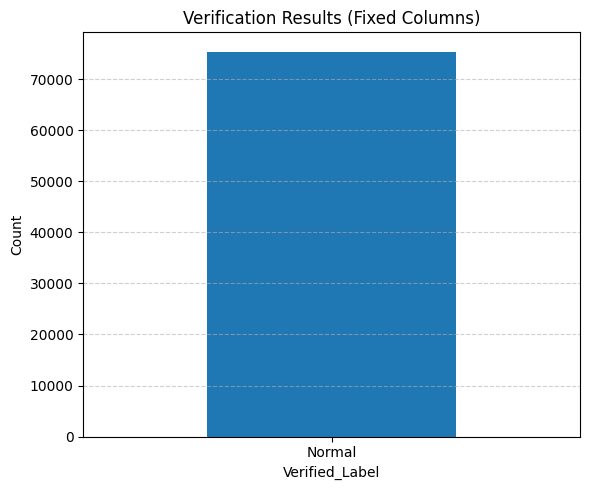

In [9]:
final_path = "/Users/yasmine/Kongsberg/data/diagnostics/outlier_verification/verified_outliers_final.csv"
fixed_path = str(Path(final_path).with_name("verified_outliers_final_fixed.csv"))

# Read raw (no header)
raw = pd.read_csv(final_path, header=None)

# We’ll force the *last 7* columns to be the ONV tail we produced
tail_cols = ["IsOutlier", "Stat_Outlier", "ONV_Agreement", "ONV_Label", "IF_Flag", "Verified_Label", "Sensor"]

# Reasonable prefix names for the front part (slice to fit)
prefix_cols_master = [
    "Timestamp","Value","ValueStatus","ExportType","TimestampPrecisionType","IncludeBadValues",
    "TotalEvents","TotalGoodValues","TotalBadValues","LowestFrequency","HighestFrequency","AverageFrequency",
    "DigitalSet","ExceptionDeviation","ExceptionMaximum","ExceptionMinimum","ExceptionPercentage",
    "Span","Zero","EngineeringUnits","Compressing","Step",
    "CompressionDeviation","CompressionMaximum","CompressionMinimum","CompressionPercentage"
]

n = raw.shape[1]
k = len(tail_cols)
if n < k + 1:
    raise ValueError(f"Unexpected column count ({n}). Expected at least {k+1} columns.")

prefix = prefix_cols_master[: max(0, n - k)]
# If the file has *more* leading columns than we expected, pad with generic names
if len(prefix) < n - k:
    prefix += [f"Meta_{i}" for i in range(1, (n - k) - len(prefix) + 1)]

raw.columns = prefix + tail_cols

# Sanity checks & quick auto-fixes
# 1) If Verified_Label looks like sensor IDs, swap the last two columns
sensor_like = raw["Verified_Label"].astype(str).str.contains(r"^LNG", na=False).mean() > 0.8
if sensor_like:
    raw[["Verified_Label", "Sensor"]] = raw[["Sensor", "Verified_Label"]].values

# 2) If IF_Flag is not numeric, coerce
raw["IF_Flag"] = pd.to_numeric(raw["IF_Flag"], errors="coerce")

# 3) Ensure Timestamp is datetime if present in prefix
if "Timestamp" in raw.columns:
    # some rows might be missing timestamp if prefix shifted—ignore errors
    raw["Timestamp"] = pd.to_datetime(raw["Timestamp"], errors="coerce")

# Save fixed file with headers
raw.to_csv(fixed_path, index=False)
print(f"Re-labeled file saved → {fixed_path}")

# ---- Final summary (now using fixed columns) ----
expected_labels = {"Normal", "Sensor Fault", "True Process Anomaly", "Unknown"}
vc = raw["Verified_Label"].value_counts(dropna=False)

print("\n=== Final Verification Summary (fixed) ===")
print(vc)

# Optional: compact chart
plt.figure(figsize=(6,5))
vc.plot(kind="bar")
plt.title("Verification Results (Fixed Columns)")
plt.xlabel("Verified_Label")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


We can see that no anomaly or sensor fault was detected. However during the EDA stage a drop in cargo was detected. The following steps are to ensure that the model can detect those drops.

Found 16 outlier files.


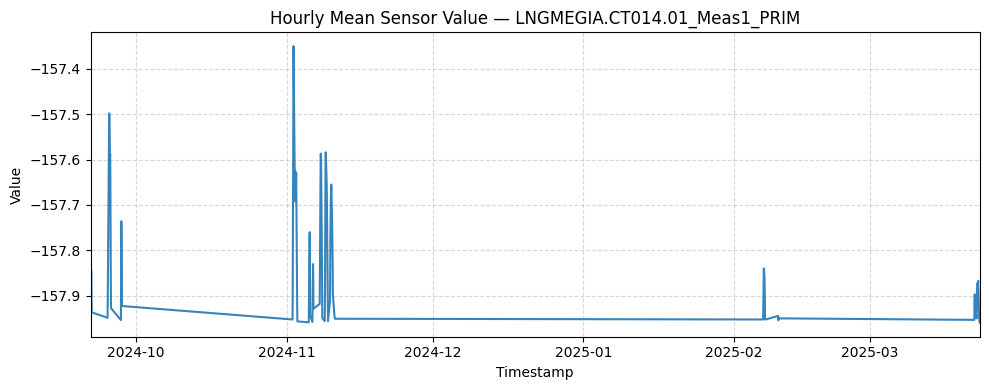

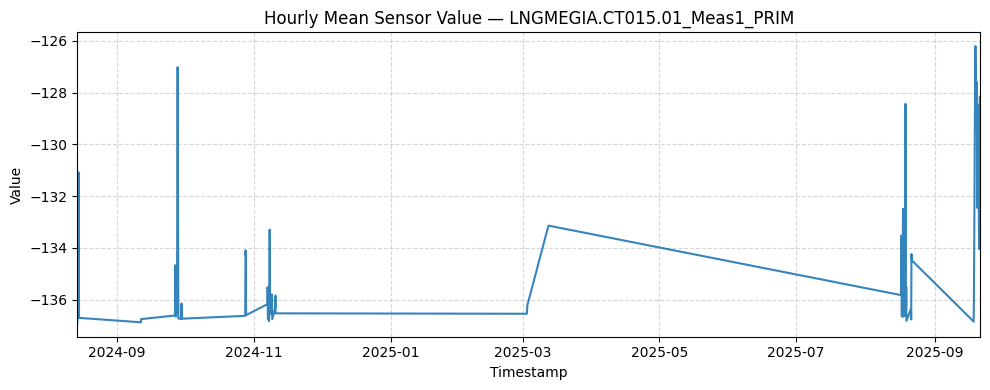

/Users/yasmine/Kongsberg/vennv/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/var/folders/62/k7w41sfd4ld3st4q9psbybc40000gq/T/ipykernel_32436/908286518.py:25: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  median_gap = pd.Timedelta("1H")
/var/folders/62/k7w41sfd4ld3st4q9psbybc40000gq/T/ipykernel_32436/908286518.py:68: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  plt.xlim(x_min, x_max)


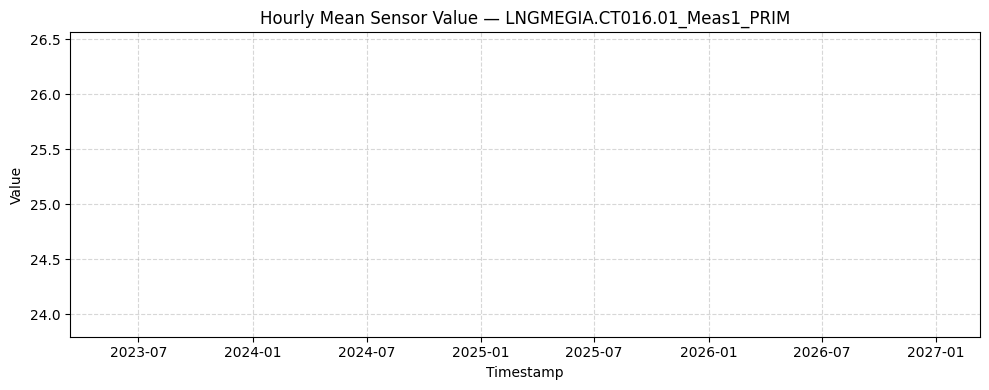

/var/folders/62/k7w41sfd4ld3st4q9psbybc40000gq/T/ipykernel_32436/908286518.py:68: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  plt.xlim(x_min, x_max)


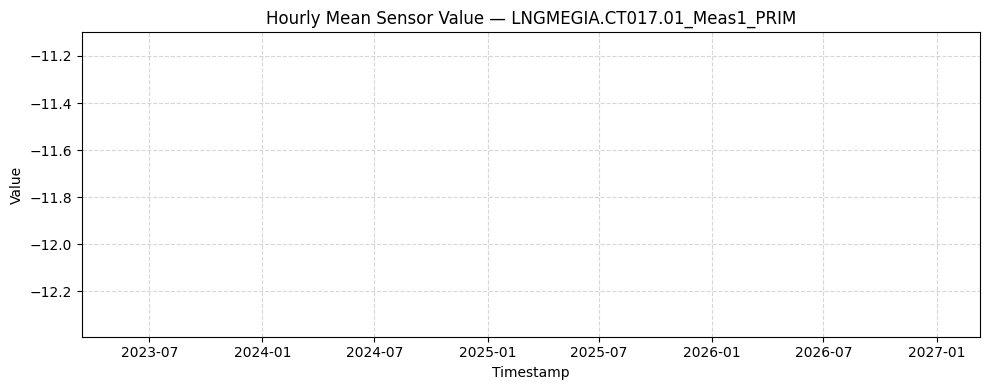

/Users/yasmine/Kongsberg/vennv/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/var/folders/62/k7w41sfd4ld3st4q9psbybc40000gq/T/ipykernel_32436/908286518.py:25: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  median_gap = pd.Timedelta("1H")
/var/folders/62/k7w41sfd4ld3st4q9psbybc40000gq/T/ipykernel_32436/908286518.py:68: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  plt.xlim(x_min, x_max)


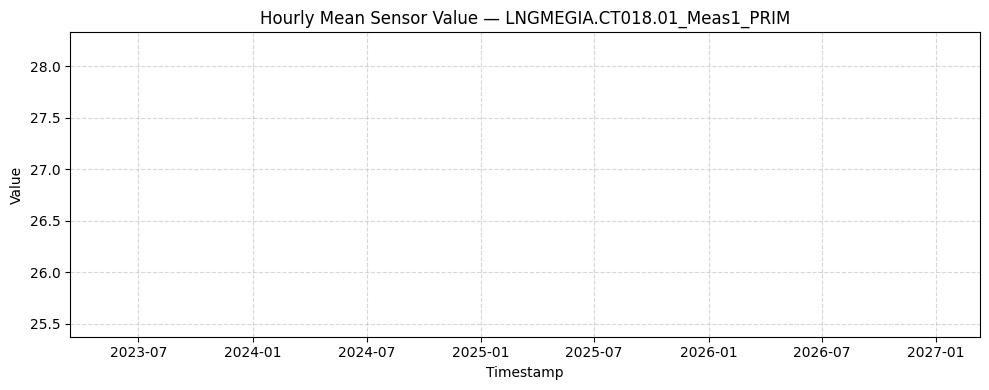

/Users/yasmine/Kongsberg/vennv/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/var/folders/62/k7w41sfd4ld3st4q9psbybc40000gq/T/ipykernel_32436/908286518.py:25: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  median_gap = pd.Timedelta("1H")
/var/folders/62/k7w41sfd4ld3st4q9psbybc40000gq/T/ipykernel_32436/908286518.py:68: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  plt.xlim(x_min, x_max)


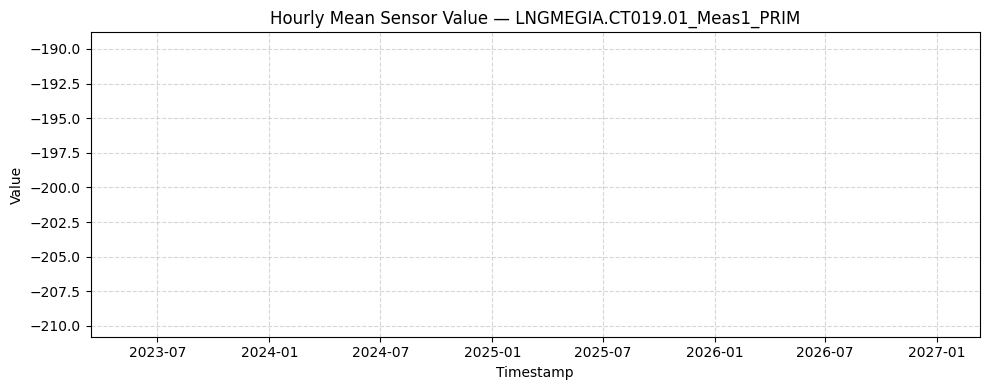

/Users/yasmine/Kongsberg/vennv/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/var/folders/62/k7w41sfd4ld3st4q9psbybc40000gq/T/ipykernel_32436/908286518.py:25: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  median_gap = pd.Timedelta("1H")
/var/folders/62/k7w41sfd4ld3st4q9psbybc40000gq/T/ipykernel_32436/908286518.py:68: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  plt.xlim(x_min, x_max)


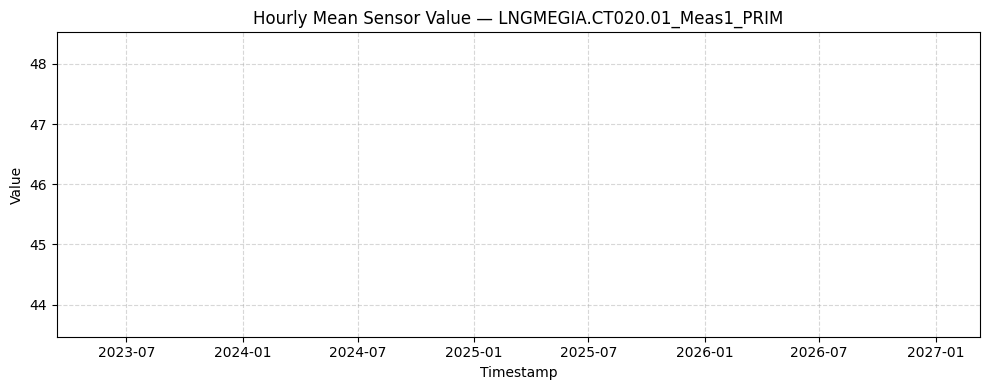

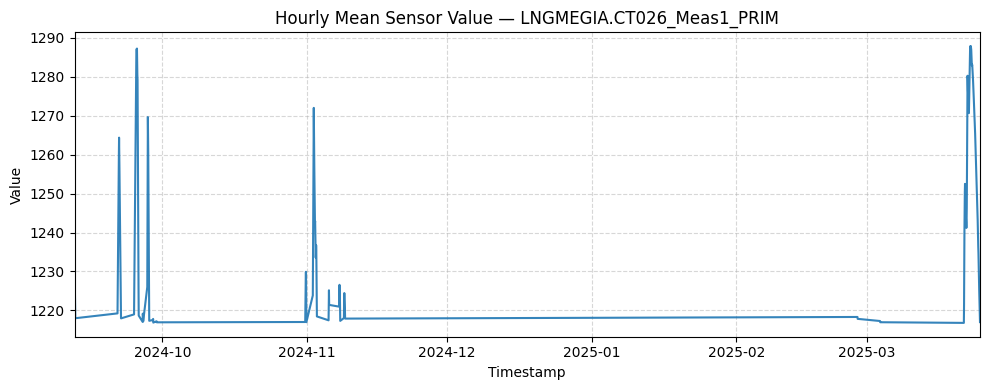

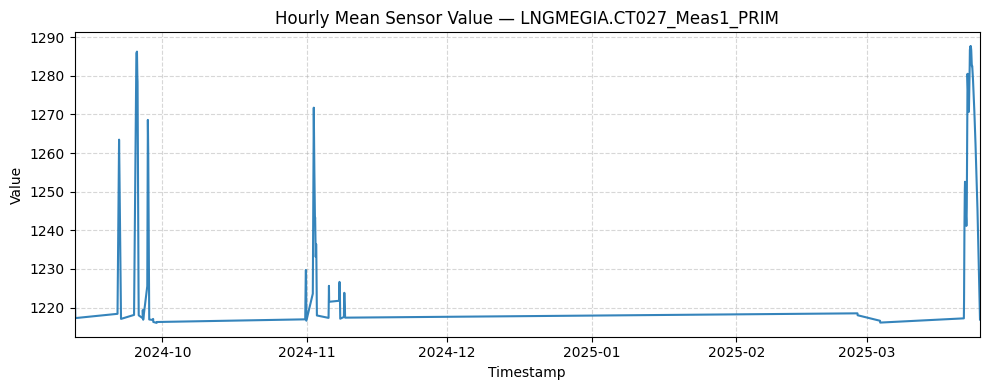

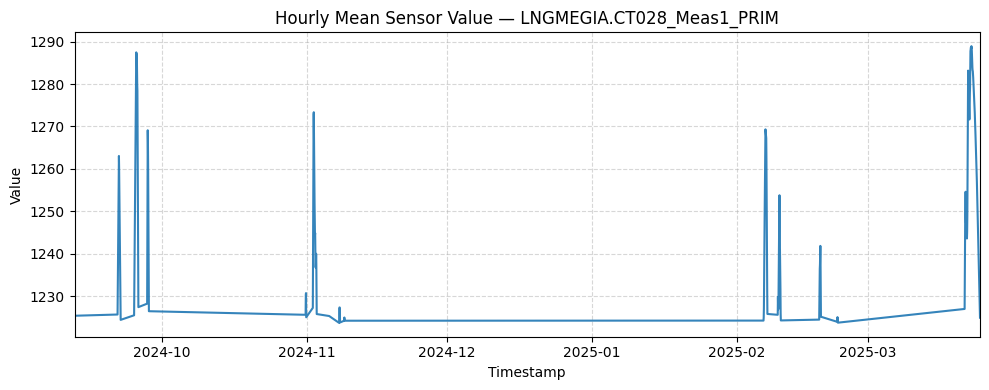

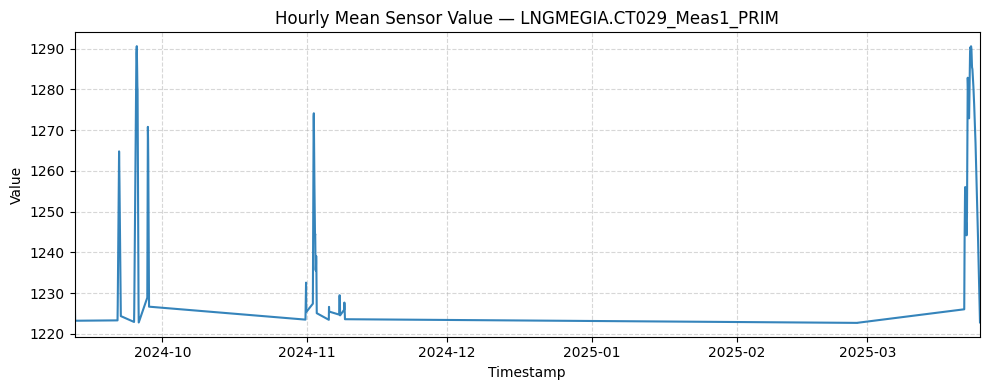

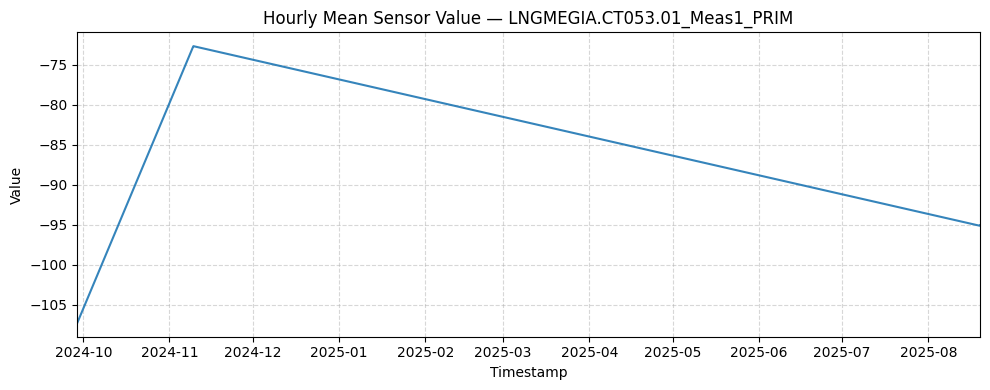

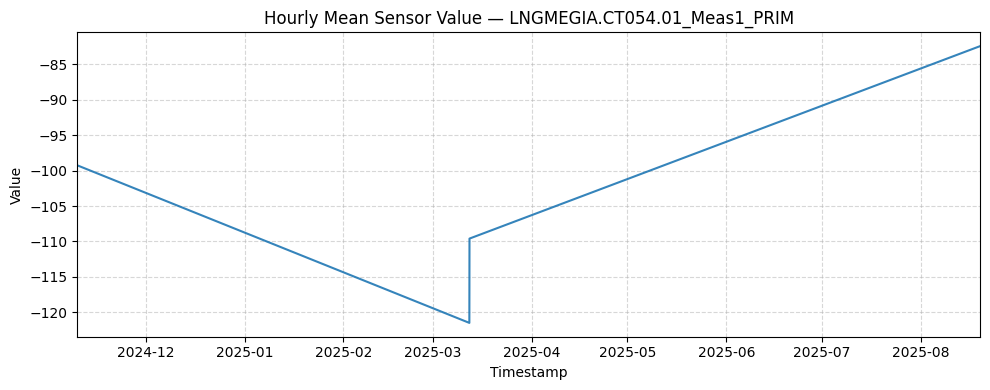

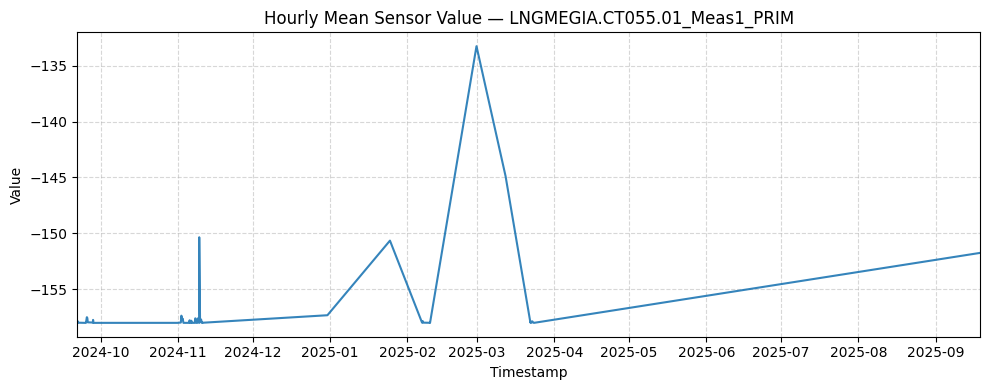

[SKIP] LNGMEGIA.CT055.02_Meas1_PRIM: all values filtered out after quantile trim.


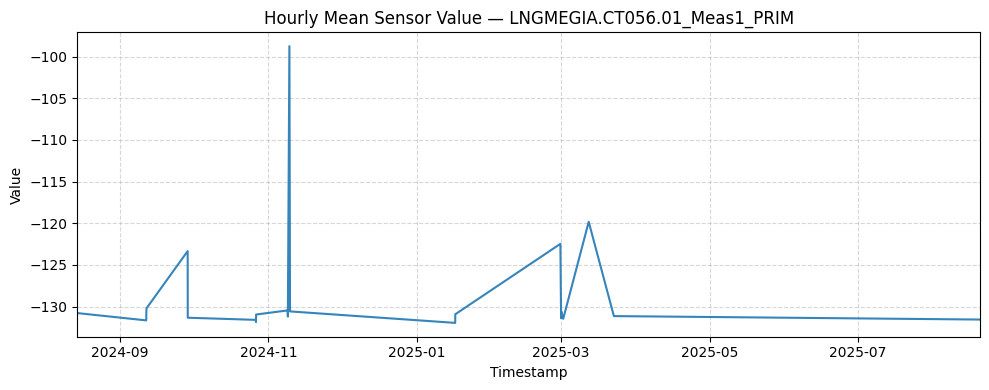

In [8]:
OUTLIER_DIR = "/Users/yasmine/Kongsberg/data/cleaned_csv/outliers"

# List all outlier files
outlier_files = sorted([f for f in os.listdir(OUTLIER_DIR) if f.endswith("_outliers.csv")])

print(f"Found {len(outlier_files)} outlier files.")

for f in outlier_files:
    sensor_name = f.replace("_outliers.csv", "")
    path = os.path.join(OUTLIER_DIR, f)
    
    try:
        df = pd.read_csv(path, parse_dates=["Timestamp"])
    except Exception as e:
        print(f"[SKIP] {sensor_name}: {e}")
        continue

    if df.empty or "Value" not in df.columns:
        print(f"[SKIP] {sensor_name}: missing 'Value' column or empty file.")
        continue

    # FIX: if very sparse, pick adaptive resample frequency
    median_gap = df["Timestamp"].sort_values().diff().median()
    if pd.isna(median_gap):
        median_gap = pd.Timedelta("1H")
    rule = "1h" if median_gap < pd.Timedelta("10min") else "6h"

    # Compute hourly/six-hour mean (adaptive)
    df_hourly = (
        df[["Timestamp", "Value"]]
        .dropna()
        .set_index("Timestamp")
        .resample(rule)
        .mean()
        .reset_index()
    )

    # handle empty or NaN-only DataFrames
    if df_hourly.empty or df_hourly["Value"].isna().all():
        print(f"[SKIP] {sensor_name}: not enough valid data after resampling.")
        continue

    # Filter out extreme outliers (robust visualization)
    df_hourly = df_hourly[df_hourly["Value"].between(
        df_hourly["Value"].quantile(0.01),
        df_hourly["Value"].quantile(0.99)
    )]

    # double-check again before plotting
    if df_hourly.empty:
        print(f"[SKIP] {sensor_name}: all values filtered out after quantile trim.")
        continue

    # safe min/max for xlim (avoid NaN error)
    x_min = df_hourly["Timestamp"].min()
    x_max = df_hourly["Timestamp"].max()
    if pd.isna(x_min) or pd.isna(x_max):
        print(f"[SKIP] {sensor_name}: invalid timestamp range.")
        continue

    # Plot
    plt.figure(figsize=(10, 4))
    plt.plot(df_hourly["Timestamp"], df_hourly["Value"], linewidth=1.5, alpha=0.9)
    plt.title(f"Hourly Mean Sensor Value — {sensor_name}")
    plt.xlabel("Timestamp")
    plt.ylabel("Value")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.xlim(x_min, x_max)
    plt.tight_layout()
    plt.show()


The ONV model didn’t flag the cargo volume drops because those periods were already removed during the cleaning step. The cleaning process filtered out invalid or extreme values, so the drops didn’t appear in the final dataset. That’s actually a good sign — it means the data going into ONV was already clean and stable, and the model correctly found no further anomalies or sensor faults.

## Next Steps
- Advance to the **Machine Learning Integration Layer**, where verified outlier patterns are used to train models for predictive diagnostics, sensor drift forecasting, and automated health confidence scoring.